# Проект. Исследование стартапов

## Введение

Цель проекта - проанализировать рынок стартапов для выяснения, в какую отрасль вложить средства и какой тип финансирования выбрать

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
#Импортируем библиотеку
!pip install missingno -q
# Загружаем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import missingno as msno

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [2]:
#Загрузим данные
df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)

In [3]:
#Загрузим данные
df_r = pd.read_csv("https://code.s3.yandex.net/datasets/cb_returns.csv",index_col='year')

Выведите информацию, которая необходима для принятия решений о предобработке.

In [4]:
#Выведем информацию по датасету
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
#Выведем первые строки датасета
df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#Посчитаем долю пропусков
df.isna().mean()

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

<a class='anchor' id="link1"></a>

<AxesSubplot:>

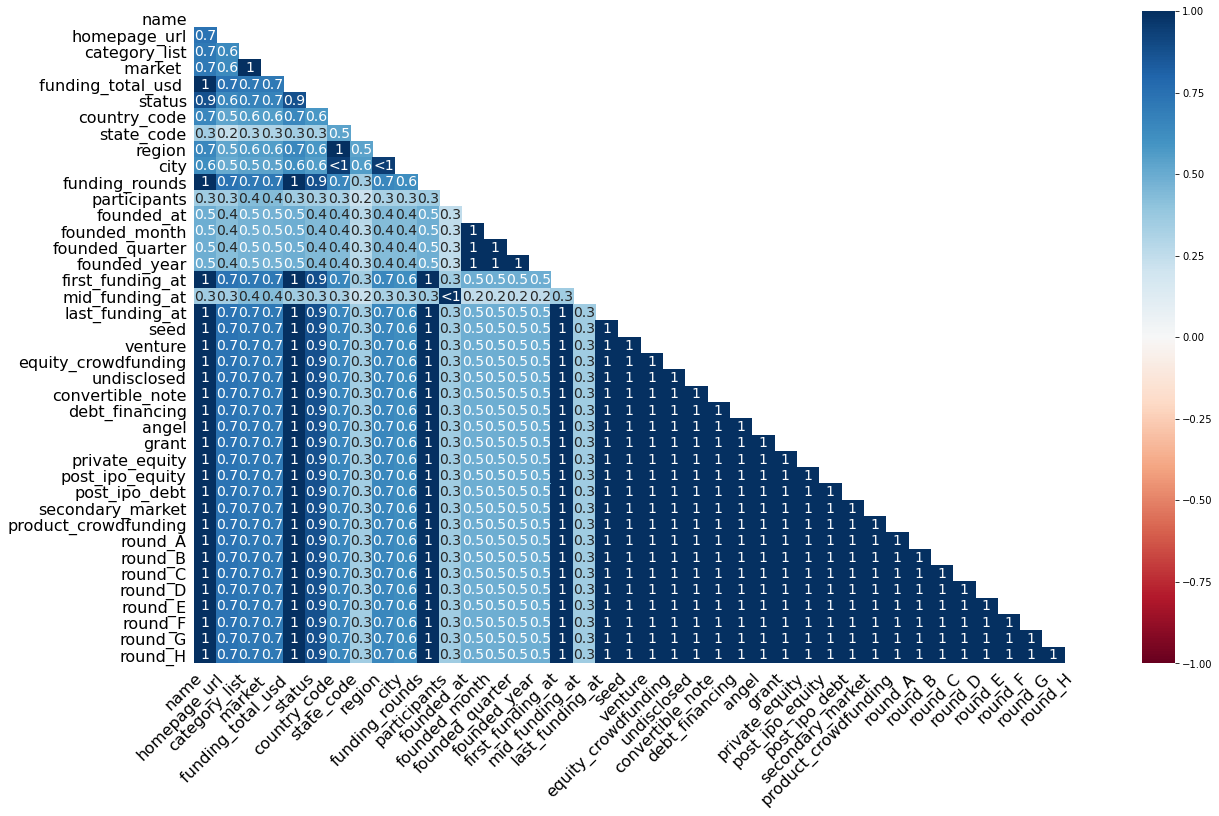

In [7]:
#Рассчитаем корреляцию пропусков
msno.heatmap(df)

Одновременно пропущены стоблцы name,funding_total_usd,first_funding_at,last_funding и колонки по типам финансирования, между этими пропусками корреляция единица.

In [8]:
#Выведем информацию по датасету
df_r.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 2000 to 2014
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   seed                  15 non-null     float64
 1   venture               15 non-null     float64
 2   equity_crowdfunding   15 non-null     float64
 3   undisclosed           15 non-null     float64
 4   convertible_note      15 non-null     float64
 5   debt_financing        15 non-null     float64
 6   angel                 15 non-null     float64
 7   grant                 15 non-null     float64
 8   private_equity        15 non-null     float64
 9   post_ipo_equity       15 non-null     float64
 10  post_ipo_debt         15 non-null     float64
 11  secondary_market      15 non-null     float64
 12  product_crowdfunding  15 non-null     float64
dtypes: float64(13)
memory usage: 1.6 KB


In [9]:
df_r.head()

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [10]:
df_r.isna().mean()

seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
post_ipo_equity         0.0
post_ipo_debt           0.0
secondary_market        0.0
product_crowdfunding    0.0
dtype: float64

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет cb_investments: В датасете 54294 строки и 40 столбцов, из них 24 типа float64 и 16 типа object, при этом стоблцы с датами тоже типа object (founded_at, first_funding_at, mid_funding_at,last_funding_at), а не дата, стоблцы founded_month, founded_quarter типа object, year, participants,funding_rounds типа float (из-за пропусков данные нельзя сразу среобразовать к типу int), столбец funding_total_usd типа object в формате с запятыми, хотя это должно быть число. Пропуски есть во всех стоблцах, но наибольшее число пропусков в стоблцах mid_funding_at (44,2%), founded_at (29%),founded_month (29,1), founded_quarter (29,1%),founded_year (29%),state_code(44,4%), participants(43,9%).Одновременно пропущены стоблцы name,funding_total_usd,first_funding_at,last_funding и колонки по типам финансирования [1](#link1)

Датасет cb_returns: В датасете 15 записей, 14 столбцов. Все столбцы с корректными типами, пропусков нет

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [11]:
#Выведем названия столбцоы
#В названиях столбцов market, funding_total_usd есть лишние пробелы
print(df.columns)

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')


Все столбцы с названиямм типа snake case, в названиях market, funding_total_usd вначале стоят пробелы, что может быть неудобно.

In [12]:
#Уберем лишние пробелы в названиях столбцов
df.columns = df.columns.str.strip()

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [13]:
#Заменяем "," на пустое множество,убираем пробелы по краям
df['funding_total_usd'] = df['funding_total_usd'].str.replace(',','')
df['funding_total_usd'] = df['funding_total_usd'].str.strip()
#Оставшийся после замены прочерк заменяем на NaN
df['funding_total_usd'] = df['funding_total_usd'].str.replace('-','NaN')

In [14]:
#Преобразуем в тип float
df['funding_total_usd']=pd.to_numeric(df['funding_total_usd'],errors='coerce')

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [15]:
#Преобразуем  данные к типу дата 'founded_month','founded_quarter',format='%Y-%m-%d'
for column in ['founded_at', 'first_funding_at','mid_funding_at','last_funding_at']:
    df[column] = pd.to_datetime(df[column],errors='coerce')

In [16]:
#Проверим типы
print(df.dtypes) 

name                            object
homepage_url                    object
category_list                   object
market                          object
funding_total_usd              float64
status                          object
country_code                    object
state_code                      object
region                          object
city                            object
funding_rounds                 float64
participants                   float64
founded_at              datetime64[ns]
founded_month                   object
founded_quarter                 object
founded_year                   float64
first_funding_at        datetime64[ns]
mid_funding_at          datetime64[ns]
last_funding_at         datetime64[ns]
seed                           float64
venture                        float64
equity_crowdfunding            float64
undisclosed                    float64
convertible_note               float64
debt_financing                 float64
angel                    

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

Установили индекс при загрузке

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [17]:
#Проверим неявные дубликаты
print (df['country_code'].unique())

['USA' nan 'DEU' 'JPN' 'CAN' 'IND' 'CHE' 'PHL' 'ISR' 'ITA' 'GBR' 'ESP'
 'DNK' 'BEL' 'MEX' 'VNM' 'NLD' 'BRA' 'AUS' 'IRL' 'FRA' 'KHM' 'SWE' 'FIN'
 'KOR' 'KEN' 'TWN' 'THA' 'AUT' 'ZAF' 'NOR' 'EGY' 'CHN' 'PAK' 'SGP' 'URY'
 'ARE' 'CZE' 'NZL' 'TUR' 'RUS' 'COL' 'NGA' 'MCO' 'MYS' 'LUX' 'LTU' 'PRT'
 'HKG' 'BGR' 'SVK' 'EST' 'ISL' 'GHA' 'POL' 'BMU' 'JOR' 'LVA' 'TUN' 'HUN'
 'IDN' 'ARG' 'MAF' 'ROM' 'MLT' 'CYP' 'UKR' 'PAN' 'TZA' 'GRC' 'BWA' 'ARM'
 'CYM' 'HRV' 'SRB' 'CHL' 'UZB' 'SLV' 'MKD' 'SVN' 'BGD' 'LBN' 'NPL' 'NIC'
 'CRI' 'UGA' 'GIB' 'PER' 'JAM' 'GTM' 'BHS' 'DZA' 'MDA' 'BLR' 'LAO' 'MAR'
 'DOM' 'CMR' 'SOM' 'SAU' 'AZE' 'BHR' 'SYC' 'MUS' 'ECU' 'MMR' 'OMN' 'TTO'
 'BRN' 'JEY' 'ALB' 'KWT' 'LIE' 'MOZ' 'ZWE' 'CIV']


In [18]:
print (df['state_code'].unique())

['MA' nan 'DE' 'MI' 'OH' 'LA' 'NC' 'VA' 'CA' 'NY' 'FL' 'MD' 'MO' 'NJ' 'OR'
 'TX' 'ME' 'KY' 'NE' 'IN' 'BC' 'AR' 'UT' 'TN' 'CT' 'DC' 'ND' 'GA' 'AZ'
 'KS' 'NM' 'PA' 'IL' 'AL' 'WI' 'MN' 'CO' 'ON' 'NS' 'ID' 'NH' 'MS' 'QC'
 'RI' 'WA' 'IA' 'AB' 'MB' 'VT' 'NV' 'SC' 'MT' 'OK' 'AK' 'SD' 'WY' 'WV'
 'HI' 'NL' 'NB' 'SK' 'PE']


In [19]:
print (df['status'].unique())

['operating' 'acquired' nan 'closed']


In [20]:
print(df['market'].unique())

[' Education ' nan ' Business Services ' ' Social Media '
 ' Hardware + Software ' ' Biotechnology ' ' Hardware + Software'
 ' Utilities ' ' Hospitality ' ' Enterprise Software ' ' Manufacturing '
 ' Pharmaceuticals ' 'Finance' 'Shipping' ' Finance ' ' Design '
 ' Nonprofits ' ' Software ' ' Curated Web ' ' Health Care ' ' Education'
 ' Health and Wellness ' ' Media ' ' Politics ' ' Clean Technology '
 'Manufacturing' ' Financial Services ' ' Consumer Electronics '
 ' Web Hosting ' 'E-Commerce' ' Automotive ' ' Local Businesses '
 ' E-Commerce ' ' Medical ' ' Fashion ' ' Advanced Materials ' ' Banking '
 'Security ' ' Publishing ' ' Networking ' ' Analytics '
 ' Semiconductors ' ' Public Relations ' ' Energy ' ' Cosmetics '
 ' Jewelry ' ' Nanotechnology ' ' Travel ' ' Retail'
 ' Public Transportation ' 'Consulting ' ' Security ' ' Construction '
 ' Real Estate ' ' Consulting ' 'Environmental Innovation ' ' Retail '
 ' Restaurants ' ' Services ' ' Technology ' ' Telecommunications '
 ' 

В названиях сегментов рынка есть пробелы с начала и конца строки, удалим их

In [21]:
df['market'] = df['market'].str.strip()

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [22]:
#Сохраним размер массива
initial_size=len(df)

In [23]:
# Проверяем полные дубликаты в датафрейме df
df.duplicated().sum()

4855

In [24]:
#Удаляем явные дубликаты
df=df.drop_duplicates()

In [25]:
#Удаляем пропуски в funding_total_usd
df = df.dropna(subset=['funding_total_usd'])

In [26]:
#Проверим, сколько пропусков осталось
df.isna().sum()

name                        1
homepage_url             2314
category_list            2503
market                   2503
funding_total_usd           0
status                   1105
country_code             3819
state_code              15288
region                   3819
city                     4505
funding_rounds              0
participants            13576
founded_at               8707
founded_month            8772
founded_quarter          8772
founded_year             8706
first_funding_at            2
mid_funding_at          13676
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_A                     0
round_B   

In [27]:
#Удалим строки с пропуском имени и даты первого финансирования
df = df.dropna(subset=['name','first_funding_at'])

In [28]:
df.duplicated(subset='name').sum()

61

Всего 61 дубликат названия, проверим другие поля

In [29]:
#Добавим другие поля
df.duplicated(subset=['name','homepage_url']).sum()

10

Значит, для одно названия несколько разных сайтов

In [30]:
#Добавим другие поля
df.duplicated(subset=['name','homepage_url','market']).sum()

3

In [31]:
#проверим оставшиеся три дубликата
duplicates =df[df.duplicated(subset=['name','homepage_url','market'],keep=False)]

In [32]:
#Выводим дубликаты
display(duplicates)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
11350,Kickserv,http://www.kickserv.com,|SaaS|Services|Software|,SaaS,1100000.0,operating,USA,CA,SF Bay Area,Mill Valley,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21434,inMarket,http://www.inmarket.com,|Apps|Hardware|Shopping|Retail|Online Reservat...,Mobile,1000000.0,operating,USA,CA,Los Angeles,Los Angeles,...,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
21444,inMarket,http://www.inmarket.com,|Mobile Shopping|Advertising|Retail|Shopping|M...,Mobile,1000000.0,operating,USA,CA,Los Angeles,Los Angeles,...,0.0,0.0,1000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26870,Kickserv,http://www.kickserv.com,|Small and Medium Businesses|SaaS|,SaaS,600000.0,operating,USA,CA,SF Bay Area,Mill Valley,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44111,GAIN Fitness,http://gainfitness.com,|Fitness|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
44112,GAIN Fitness,http://gainfitness.com,|Health and Wellness|,Health and Wellness,2790000.0,operating,USA,CA,SF Bay Area,San Francisco,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Различное поле список_категорий, поэтому не будем удалять дубликаты.

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [33]:
# Вычисляем середину интервала (в наносекундах, чтобы избежать проблем с timedelta)
mid_dates = df['first_funding_at'] + ((df['last_funding_at'] - df['first_funding_at']) / 2)

In [34]:
df['mid_funding_at'] = df['mid_funding_at'].fillna(mid_dates)

In [35]:
#Проверим, сколько пропусков осталось
df.isna().mean()

name                    0.000000
homepage_url            0.056571
category_list           0.061192
market                  0.061192
funding_total_usd       0.000000
status                  0.027014
country_code            0.093341
state_code              0.373704
region                  0.093341
city                    0.110111
funding_rounds          0.000000
participants            0.331850
founded_at              0.212864
founded_month           0.214453
founded_quarter         0.214453
founded_year            0.212840
first_funding_at        0.000000
mid_funding_at          0.000000
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [36]:
#Посчитаем размер массива
cleaned_size=len(df)

In [37]:
#Посчидаем долю удаленных данных
share_cleaned=100*(initial_size-cleaned_size)/initial_size

In [38]:
#Выведем на экран
print(f'Доля удаленных строк:{round(share_cleaned,4)}%')
print(f'Количество оставшихся строк:{cleaned_size}')

Доля удаленных строк:24.662%
Количество оставшихся строк:40904


Осталось 40904 строк, что достаточно для решения задач проекта, отброшено 24,7% данных.

In [39]:
#Проверим, что дата последнего финансирования больше даты первого финансирования
print(df[df['last_funding_at']<df['first_funding_at']])

Empty DataFrame
Columns: [name, homepage_url, category_list, market, funding_total_usd, status, country_code, state_code, region, city, funding_rounds, participants, founded_at, founded_month, founded_quarter, founded_year, first_funding_at, mid_funding_at, last_funding_at, seed, venture, equity_crowdfunding, undisclosed, convertible_note, debt_financing, angel, grant, private_equity, post_ipo_equity, post_ipo_debt, secondary_market, product_crowdfunding, round_A, round_B, round_C, round_D, round_E, round_F, round_G, round_H]
Index: []

[0 rows x 40 columns]


In [40]:
display(df[df['founded_at']>df['first_funding_at']])

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
693,Morcom International,http://www.morcom.com,|Wireless|Music|Mobile|,Mobile,100000.0,operating,USA,VA,"Washington, D.C.",Chantilly,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1489,JAD Tech Consulting,http://www.jadtech.com,|Project Management|Consulting|,Consulting,125000.0,operating,USA,TX,Dallas,Richardson,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1493,Market Wire,http://www.marketwired.com/,|Advertising|,Advertising,28150000.0,operating,USA,CA,Los Angeles,El Segundo,...,0.0,0.0,21550000.0,2000000.0,0.0,4600000.0,0.0,0.0,0.0,0.0
1874,GeoCities,NaN,|Web Hosting|,Web Hosting,40000000.0,acquired,USA,CA,Los Angeles,Marina Del Rey,...,0.0,0.0,2000000.0,8000000.0,5000000.0,25000000.0,0.0,0.0,0.0,0.0
2149,Ask.com,http://www.ask.com,|Search|Social Media|,Social Media,25000000.0,acquired,USA,CA,SF Bay Area,Oakland,...,0.0,0.0,25000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38527,"Almond Systems, Inc.",http://www.almond-systems.com,|Health and Wellness|,Health and Wellness,9000000.0,operating,USA,CA,SF Bay Area,Palo Alto,...,0.0,0.0,9000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38531,Droppie,http://www.droppie.com,NaN,NaN,310000.0,operating,USA,CA,San Diego,San Diego,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38534,The Viridan Group,NaN,|Hospitality|,Hospitality,2500000.0,operating,USA,MI,Detroit,Southfield,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
38551,Manifatto,http://manifatto.com,|E-Commerce|,E-Commerce,30000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Найдено 2129 компаний, для которых  дата основания позже даты финансирования. Так как дата основания не используется в дальнейшем в нашем исследовании, не будем удалять данные.

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [41]:
#Напишем функцию для распределения на группы финансирования
from datetime import timedelta
def categorize_finance(row):
    """
    Функция проводит классификацию по типу финансирования
    """
      
    if row['first_funding_at']==row['last_funding_at']:
        return 'Единичное финансирование'
    elif row['last_funding_at']-row['first_funding_at']<timedelta(days=365):
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'        

In [42]:
#Применяем функцию для категоризации
df['finance_category'] = df.apply(categorize_finance, axis=1)

In [43]:
#Сгруппируем и рассчитаем доли
grouped = df.groupby('finance_category')['name'].count()/df['name'].count()

In [44]:
#Сгруппируем и расчитаем доли
grouped2 = df.groupby('finance_category')['funding_total_usd'].sum()/df['funding_total_usd'].sum()

<a class='anchor' id="link3"></a>

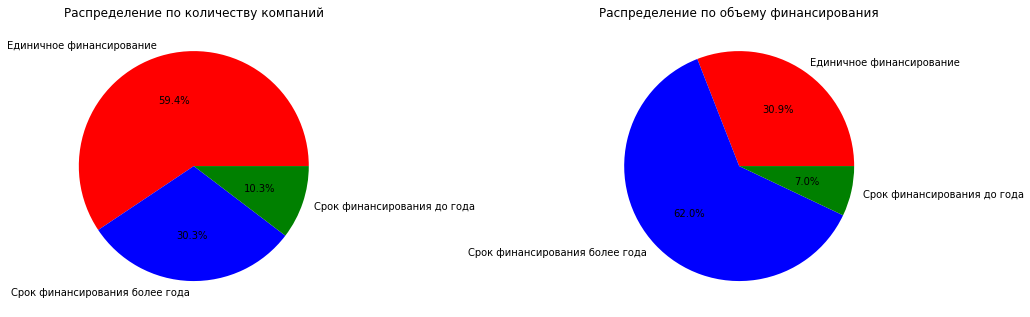

In [45]:
# Создаем фигуру с 1 строкой и 2 столбцами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Первая диаграмма (слева)
grouped.plot(
    kind='pie', 
    y=grouped.columns[0] if hasattr(grouped, 'columns') else None,
    ax=ax1, # <--- указываем первую область
    title='Распределение по количеству компаний', 
    legend=False, 
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green']
)
ax1.set_ylabel('')

# Вторая диаграмма (справа)
# Замените 'grouped2' на данные для вашей второй диаграммы
grouped2.plot(
    kind='pie', 
    y=grouped.columns[0] if hasattr(grouped, 'columns') else None,
    ax=ax2, # <--- указываем вторую область
    title='Распределение по объему финансирования', 
    legend=False, 
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green']
)
ax2.set_ylabel('')

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()



По количеству компаний лидирует единичное финансирование, составив 59%, по объему средства лидирует финансирование со сроком более года, составит 62% всего финансирования.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

In [46]:
#Группируем по сегментам рынка
grouped3=df.groupby('market')['name'].count()

In [47]:
grouped3=grouped3.reset_index()

In [48]:
grouped3.rename(columns={'name':'name_count'}, inplace=True)

In [49]:
#Создаем функцию для сегментации рынка
def categorize_market(x):
    """ 
    Категоризация сегмента рынка
    """
    if pd.isna(x):
        return np.nan
    elif x >120:
        return 'массовый'
    elif x>=35:
        return 'средний'
    else:
        return 'нишевый'

In [50]:
#Применим функцию к датасету
grouped3['market_segment'] = grouped3['name_count'].apply(categorize_market)

In [51]:
grouped4=grouped3.groupby('market_segment')['market'].count()

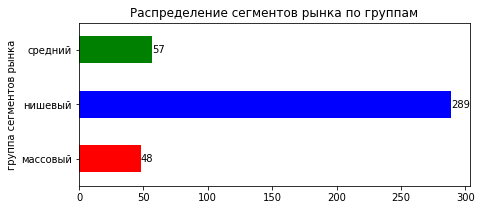

In [52]:
# Строим график и сохраняем объект осей в переменную ax
ax = grouped4.plot(
    kind='barh', 
    title='Распределение сегментов рынка по группам', 
    legend=False, 
    xlabel='группа сегментов рынка', 
    rot=0, 
    figsize=(7, 3), 
    color=['red','blue','green']
)

# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )

plt.show()


Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки — `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно — они объединяются в два общих сегмента.


In [53]:
#Объединим два датасета
df1=pd.merge(df,grouped3,on='market',how='left')

In [54]:
def categorize_market2(row):
    """ 
    Категоризация режима работы заведения
    """
    if pd.isna(row['name_count']):
        return np.nan
    elif row['name_count'] >120:
        return row['market']
    elif row['name_count'] >=35:
        return 'mid'
    else:
        return 'niche'

In [55]:
df1['market']=df1.apply(categorize_market2, axis=1)

In [56]:
#Проверим сегмент market
df1.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,round_B,round_C,round_D,round_E,round_F,round_G,round_H,finance_category,name_count,market_segment
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.0,operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,844.0,массовый
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,2000000.0,operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,NaN,NaN
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,mid,9000000.0,operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,73.0,средний
3,University of Michigan,http://www.umich.edu/,|Education|,Education,7700000.0,operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Срок финансирования до года,844.0,массовый
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,540000.0,operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Единичное финансирование,844.0,массовый


Больше всего нишевых сегментов рынка-289, массовых сегментов-48,средних сегментов-57

In [57]:
#Сгруппируем и рассчитаем доли
grouped40 = df1.groupby('market_segment')['name'].count()

In [58]:
grouped41=df1.groupby('market_segment')['funding_total_usd'].sum()

<a class='anchor' id="link2"></a>

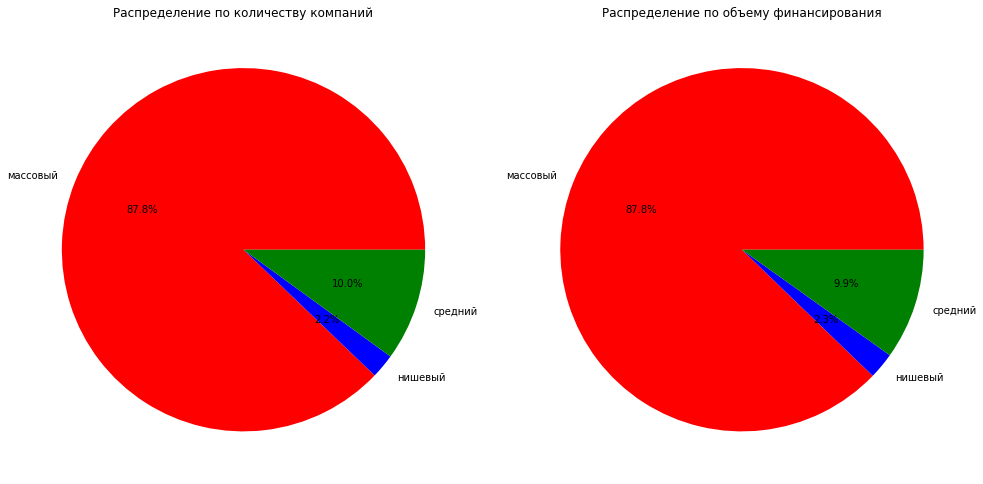

In [59]:
# Создаем фигуру с 1 строкой и 2 столбцами
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Первая диаграмма (слева)
grouped40.plot(
    kind='pie', 
    y=grouped.columns[0] if hasattr(grouped, 'columns') else None,
    ax=ax1, # <--- указываем первую область
    title='Распределение по количеству компаний', 
    legend=False, 
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green']
)
ax1.set_ylabel('')

# Вторая диаграмма (справа)
# Замените 'grouped2' на данные для вашей второй диаграммы
grouped41.plot(
    kind='pie', 
    y=grouped.columns[0] if hasattr(grouped, 'columns') else None,
    ax=ax2, # <--- указываем вторую область
    title='Распределение по объему финансирования', 
    legend=False, 
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green']
)
ax2.set_ylabel('')

plt.tight_layout() # Чтобы графики не наезжали друг на друга
plt.show()

Примерно 90% компаний и 90% объема финансирования идет на массовый сегмент рынка, что позволяет сосредоточиться на наиболее востребованных отраслях, нишевой сегмент несмотря на наибольшее количество наименований сегментов рынка, составляет только 2.2% по количеству компаний и 2.3% по объему финансирования. То есть инвесторы не рискуют вкладывать в редкие виды деятельности, предпочитая массовый рынок.

In [60]:
#Отберем компании массового сегмента
df11=df1[(df1['market']!='mid')&(df1['market']!='niche')]

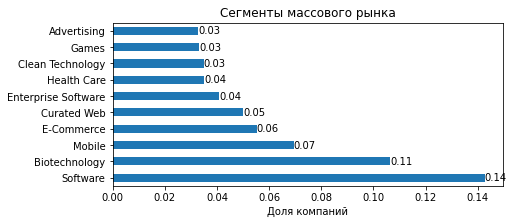

In [61]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим горизонтальную столбчатую диаграмму с помощью pandas через plot(kind='bar')
ax=df11['market'].value_counts(normalize=True).head(10).plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Сегменты массового рынка'
)

for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.2f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )

# Настраиваем оформление графика
plt.xlabel('Доля компаний')

# Добавляем сетку графика

# Выводим график
plt.show()

Самым распространенным сегментом среди массовых сегментов по количеству компаний является программное обеспечение (14% всех компаний),  на втором месте - биотехнологии (11%), на третьем - мобильная связь (7%), то есть стартапы сосредоточены в наиболее высокотехнологичных отраслях.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся. Укажите интервал, в котором лежат типичные значения.

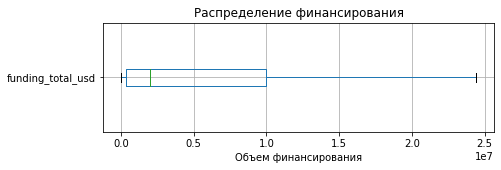

In [62]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце
df1.boxplot(column='funding_total_usd', vert=False, showfliers=False)

# Добавляем заголовок и метки оси
plt.title('Распределение финансирования')
plt.xlabel('Объем финансирования')

# Выводим график
plt.show()

In [63]:
df1['funding_total_usd'].describe()

count    4.090400e+04
mean     1.591285e+07
std      1.686850e+08
min      1.000000e+00
25%      3.500000e+05
50%      2.000000e+06
75%      1.000000e+07
max      3.007950e+10
Name: funding_total_usd, dtype: float64

На графике видно, что 50% данных лежит в интервале от 1 до 10 000 000. Медиана - 2 000 000. IQR=10 000 000-350 000=9 650 000 Левая граница=max(350 000-9 650 000Х1.5,1)=1 Правая граница=10 000 000+1.5Х9 650 000=24 475 000 В итоге метод IQR дает границы показателя от 1 до 24 475 000, значения выше 24 475 000 выбросы.

Определите компании с аномальным объёмом общего финансирования — используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние — в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [64]:
market_list=df1['market'].unique()

In [65]:
#Создаем пустые списки
cat1=[]
cat2=[]
cat3=[]
#Заполняем списки нижними и верхними границами для выбросов и сегментом
for cat in market_list:
    grouped5 = df1[(df1['market']==cat)]
    q25=grouped5['funding_total_usd'].quantile(0.25)
    q75=grouped5['funding_total_usd'].quantile(0.75)
    min_s=grouped5['funding_total_usd'].min()
    max_s=grouped5['funding_total_usd'].max()
    lb=max(min_s,q25-(q75-q25)*1.5)
    ub=min(max_s,q75+(q75-q25)*1.5)
    cat1.append(cat)
    cat2.append(lb)
    cat3.append(ub)
data={'market':cat1,
       'lb':cat2,
       'ub':cat3
       }
#Создаем датафрейм
df2 = pd.DataFrame(data)
#Выводим датафрейм на экран
print(df2)

                  market       lb            ub
0              Education    890.0  1.182108e+07
1                    NaN      NaN           NaN
2                    mid    100.0  1.908762e+07
3           Social Media   1000.0  7.312500e+06
4    Hardware + Software   1100.0  2.679238e+07
5          Biotechnology   1000.0  5.282918e+07
6            Hospitality    500.0  1.726250e+07
7    Enterprise Software   5000.0  3.600000e+07
8          Manufacturing   4900.0  3.305388e+07
9                Finance   1000.0  3.288675e+07
10                Design      1.0  1.251000e+07
11                 niche    100.0  1.324432e+07
12            Nonprofits   3000.0  1.115515e+07
13              Software     22.0  2.050000e+07
14           Curated Web   1000.0  1.157500e+07
15           Health Care   5000.0  6.737500e+07
16   Health and Wellness   3750.0  1.888990e+07
17      Clean Technology   3000.0  6.824155e+07
18           Web Hosting   3766.0  5.977000e+07
19            E-Commerce    100.0  1.580

In [66]:
#Объединим два датасета
df3=pd.merge(df1,df2,on='market',how='left')

In [67]:
def categorize_outlier(row):
    """ 
    Категоризация выброса
    """
    if pd.isna(row['funding_total_usd']):
        return np.nan
    elif (row['funding_total_usd'] >row['ub']) | (row['funding_total_usd'] <row['lb']):
        return 1
    else:
        return 0

In [68]:
#введем категорию выброса
df3['outlier']=df3.apply(categorize_outlier, axis=1)

In [69]:
#Считаем долю выбросов
grouped6=df3.groupby('market')['outlier'].mean()

In [70]:
df_old=df3.copy()

In [71]:
#Сбросим индекс
grouped6=grouped6.reset_index()

In [72]:
#Отсортируем массив
grouped6=grouped6.sort_values(by='outlier', ascending=False)

<a class='anchor' id="link4"></a>

In [73]:
#Выведем лидеры по доле выбросов
grouped6.head()

,market,outlier
34,Real Estate,0.172043
14,Entertainment,0.166667
8,Consulting,0.166189
36,Search,0.164948
7,Cloud Computing,0.164474


Сегментом с наибольшим количеством выбросов является недвижимость (17.2% выбросов), замыкает пятерку облачные компьютеры (16.4% выбросов)

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [74]:
#Рассчитаем месяц и год финансирования по средней дате финансирования
df3['fin_month']=df3['mid_funding_at'].dt.month
df3['fin_year']=df3['mid_funding_at'].dt.year

In [75]:
#Отберем данные за 2014 год
df4=df3[df3['fin_year']==2014]

In [76]:
#Посчитаем финансирование по месяцам
grouped7=df4.groupby('fin_month')['funding_total_usd'].sum()

In [77]:
#Выведем на экран
print(grouped7)

fin_month
1     6.081434e+09
2     7.079744e+09
3     7.684247e+09
4     9.915091e+09
5     3.955647e+09
6     6.512559e+09
7     1.591875e+10
8     6.284361e+09
9     6.023723e+09
10    5.895224e+09
11    2.644587e+09
12    2.003883e+08
Name: funding_total_usd, dtype: float64


In [78]:
#Посчитаем количествоо фирм по месяцам
grouped71=df4.groupby('fin_month')['name'].count()

In [79]:
print(grouped71)

fin_month
1     739
2     600
3     676
4     645
5     600
6     740
7     687
8     559
9     547
10    497
11    306
12     23
Name: name, dtype: int64


Данные по финансированию есть за каждый месяц года, однако количество фирм резко снижается за декабрь, возможно, в декабре учтены не все фирмы

In [80]:
#Отберем не выбросы
df5=df3[df3['outlier']==0]

In [81]:
#Посчитаем число раундов финансирования по годам
grouped7=df5.groupby('fin_year')['funding_rounds'].sum()

In [82]:
grouped7=grouped7.reset_index()

In [83]:
grouped7.rename(columns={'funding_rounds':'funding_rounds_year'}, inplace=True)

In [84]:
df5=pd.merge(df5,grouped7,on='fin_year',how='left')

In [85]:
df5=df5[df5['funding_rounds_year']>50]

In [86]:
print('Актуальные годы:')
print(df5['fin_year'].unique())

Актуальные годы:
[2014 2009 2013 2007 2012 2010 2008 2011 2005 2004 2006 2001 2002 2000
 2003]


### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

In [87]:
#Создаем список столбцов
fin_list=['seed','venture','equity_crowdfunding','undisclosed','convertible_note','debt_financing','angel','grant',
          'private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']
#Создаем пустые списки
cat1=[]
cat2=[]
#Заполняем списки типом финансирования и суммой
for cat in fin_list:
    funding=df5[cat].sum()
    cat1.append(cat)
    cat2.append(funding)
    
data={'financing_type':cat1,
       'financing_sum':cat2,
       }
#Создаем датафрейм
df6 = pd.DataFrame(data)
#Выводим датафрейм на экран и проверяем
print(df6)

          financing_type  financing_sum
0                   seed   9.494103e+09
1                venture   1.339872e+11
2    equity_crowdfunding   2.629606e+08
3            undisclosed   2.924353e+09
4       convertible_note   5.671449e+08
5         debt_financing   1.430518e+10
6                  angel   2.501264e+09
7                  grant   2.168263e+09
8         private_equity   9.244413e+09
9        post_ipo_equity   5.099300e+09
10         post_ipo_debt   4.286718e+09
11      secondary_market   1.240862e+08
12  product_crowdfunding   1.933103e+08


In [88]:
df6=df6.sort_values(by='financing_sum', ascending=False)

In [89]:
df6=df6.set_index('financing_type')

<a class='anchor' id="link5"></a>

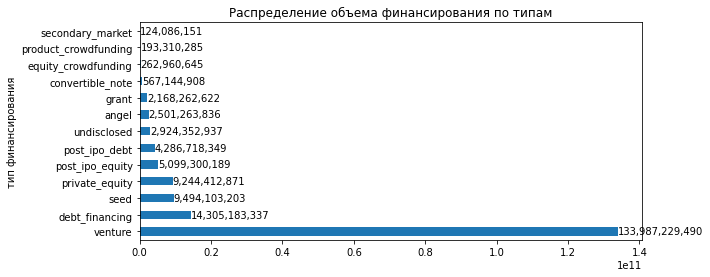

In [90]:
# Строим график и сохраняем объект осей в переменную ax
ax = df6.plot(
    kind='barh', 
    title='Распределение объема финансирования по типам', 
    legend=False, 
    xlabel='тип финансирования', 
    rot=0, 
    figsize=(9, 4), 
    )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
plt.show()

In [91]:
#Создаем пустые списки
cat1=[]
cat2=[]
#Заполняем списки типом финансирования и количеством больше нуля
for cat in fin_list:
    grouped9=df5[df5[cat]>0]
    funding_count=grouped9['name'].count()
    cat1.append(cat)
    cat2.append(funding_count)
    
data={'financing_type':cat1,
       'financing_count':cat2,
       }
#Создаем датафрейм
df7 = pd.DataFrame(data)
#Выводим датафрейм на экран и проверяем
print(df7)

          financing_type  financing_count
0                   seed            13387
1                venture            19060
2    equity_crowdfunding              516
3            undisclosed              834
4       convertible_note              522
5         debt_financing             3312
6                  angel             2938
7                  grant             1020
8         private_equity              679
9        post_ipo_equity              177
10         post_ipo_debt               29
11      secondary_market                8
12  product_crowdfunding              205


In [92]:
df7=df7.sort_values(by='financing_count', ascending=False)

In [93]:
df7=df7.set_index('financing_type')

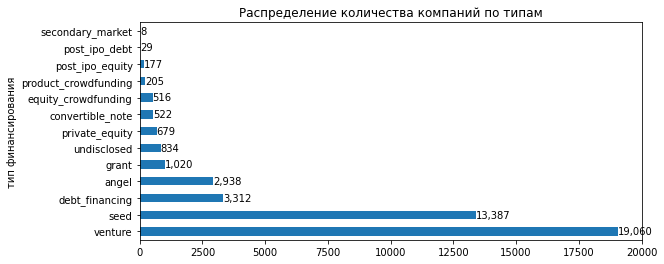

In [94]:
# Строим график и сохраняем объект осей в переменную ax
ax = df7.plot(
    kind='barh', 
    title='Распределение количества компаний по типам', 
    legend=False, 
    xlabel='тип финансирования', 
    rot=0, 
    figsize=(9, 4), 
    )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
plt.show()

Тип angel и grant часто встречается, при этом характеризуется небольшими объемами финансирования. Тип post_ipo_debt и post_ipo_equity редко встречается, при этом характеризуется значительными объемами финансирования

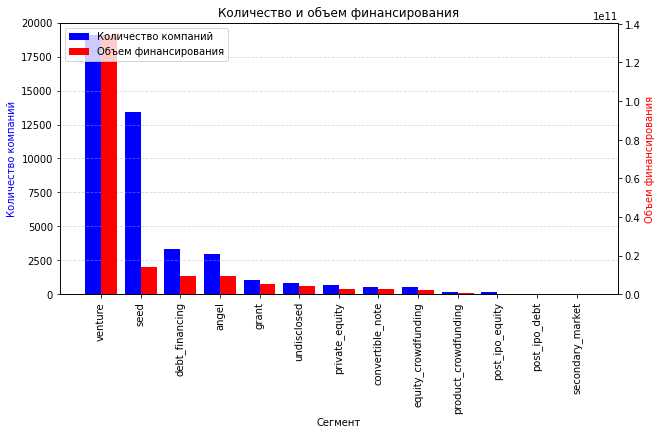

In [95]:
# --- Настройка графиков ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Параметры для разделения
bar_width = 0.4  # Ширина одного столбца
x = np.arange(len(df7))  # Позиции X (0, 1, 2, ...)

# 1. Столбчатая диаграмма 1 (смещена влево)
ax1.bar(x - bar_width/2, df7['financing_count'], 
        width=bar_width, color='blue', label='Количество компаний')

# Настройка оси X (названия сегментов)
ax1.set_xticks(x)
ax1.set_xticklabels(df7.index,rotation=90)

# 2. Создаем вторую ось
ax2 = ax1.twinx()

# 3. Столбчатая диаграмма 2 (смещена вправо)
ax2.bar(x + bar_width/2, df6['financing_sum'], 
        width=bar_width, color='red', label='Объем финансирования')

# --- Настройка подписей и сетки ---
ax1.set_ylabel('Количество компаний', color='blue')
ax2.set_ylabel('Объем финансирования', color='red')
ax1.set_xlabel('Сегмент')
plt.title('Количество и объем финансирования')

# Объединение легенды (для двух осей)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

plt.show()

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

In [96]:
#Создаем пустые списки
cat1=[]
cat2=[]
#Заполняем списки типом финансирования и суммой
for cat in fin_list:
    financing_sum_r=1000000*df_r[cat].sum()
    cat1.append(cat)
    cat2.append(financing_sum_r)
    
data={'financing_type':cat1,
       'financing_sum_r':cat2,
       }
#Создаем датафрейм
df8 = pd.DataFrame(data)
#Выводим датафрейм на экран и проверяем
print(df8)

          financing_type  financing_sum_r
0                   seed     2.382240e+09
1                venture     4.057862e+10
2    equity_crowdfunding     3.830000e+06
3            undisclosed     7.308800e+08
4       convertible_note     3.479000e+07
5         debt_financing     4.734850e+09
6                  angel     1.509230e+09
7                  grant     0.000000e+00
8         private_equity     3.587330e+09
9        post_ipo_equity     1.104960e+09
10         post_ipo_debt     9.103000e+07
11      secondary_market     5.200000e+06
12  product_crowdfunding     1.860000e+06


In [97]:
df8=df8.sort_values(by='financing_sum_r', ascending=False)

In [98]:
df8=df8.set_index('financing_type')

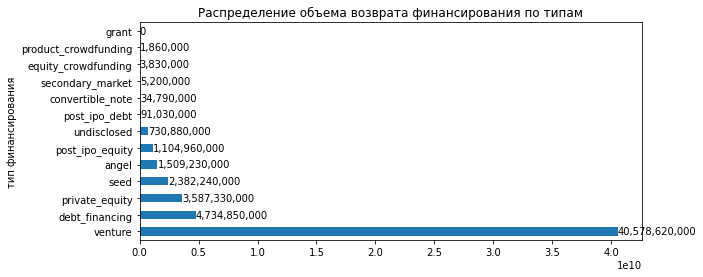

In [99]:
# Строим график и сохраняем объект осей в переменную ax
ax = df8.plot(
    kind='barh', 
    title='Распределение объема возврата финансирования по типам', 
    legend=False, 
    xlabel='тип финансирования', 
    rot=0, 
    figsize=(9, 4), 
    )
# Проходим циклом по всем прямоугольникам (столбцам) на графике
for p in ax.patches:
    # Получаем ширину столбца (это и есть наше значение)
    width = p.get_width()
    
    # Добавляем текст
    ax.text(
        width,           # Позиция по горизонтали (сразу после конца бара)
        p.get_y() + p.get_height() / 2,  # Позиция по вертикали (центр бара)
        f'{width:,.0f}', # Форматирование числа (здесь с разделителем тысяч)
        va='center',     # Выравнивание по центру относительно координаты y
        ha='left'        # Выравнивание текста по левому краю от точки вставки
    )
plt.show()

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [100]:
df_filt=df5.copy()

In [101]:
#Рассчитаем средний размер одного раунда финансирования
df_filt['avg_fin_round']=df_filt['funding_total_usd']/df_filt['funding_rounds']

In [102]:
grouped10=df_filt.groupby('fin_year')['avg_fin_round'].median()

<a class='anchor' id="link6"></a>

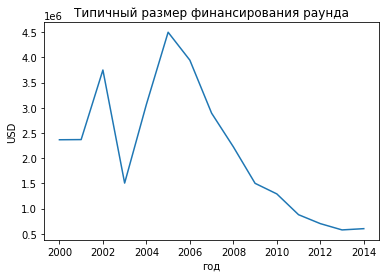

In [103]:
# Строим график
grouped10.plot(
    kind='line',
    title='Типичный размер финансирования раунда', 
    legend=False, 
    xlabel='год', 
    ylabel='USD'
    )
plt.show()

In [104]:
grouped11=df_filt.groupby('fin_year')['funding_rounds'].sum()

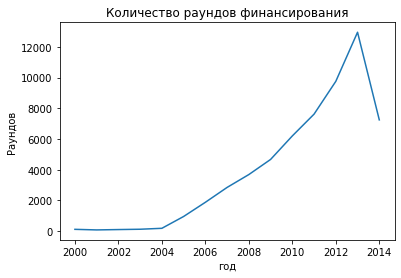

In [105]:
# Строим график
grouped11.plot(
    kind='line',
    title='Количество раундов финансирования', 
    legend=False, 
    xlabel='год', 
    ylabel='Раундов'
    )
plt.show()

Типичный размер средств в рамках одного раунда был максимальным в 2005 году В 2014 году наблюдалось падение типичного раунда финансирования и количества раундов

На рынке стартапов возможно произошла переориентация инвесторов на снижение уровня риска, когда объем вложений на каждой стадии меньше, а стадий инвестирования и контрольных точек больше. Кроме того, порог входа для инвесторов снижается, а количество инвесторов растет.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

In [106]:
#Построим таблицу
pivot_sum_funding = pd.pivot_table(
    df_filt,
    index='market',
    columns='fin_year',
    values='funding_total_usd',
    aggfunc='sum'
)

In [107]:
pivot_sum_funding.style.background_gradient(cmap='coolwarm', axis=0)

fin_year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
market,,,,,,,,,,,,,,,
Advertising,14470000.000000,8778321.000000,24500000.000000,10500000.000000,6000000.000000,127196022.000000,299299458.000000,556704331.000000,622673464.000000,563446005.000000,631617869.000000,410730737.000000,521137032.000000,524915135.000000,207792333.000000
Analytics,14822803.000000,nan,7500000.000000,3840000.000000,3000000.000000,79014044.000000,139701311.000000,98829000.000000,208077840.000000,140949327.000000,253739903.000000,443333373.000000,539214309.000000,622821367.000000,151461613.000000
Apps,nan,nan,nan,nan,nan,nan,1310600.000000,nan,4300000.000000,7219000.000000,6123779.000000,18374071.000000,32601125.000000,28868621.000000,66237730.000000
Automotive,nan,nan,nan,4530000.000000,nan,22500000.000000,12660000.000000,37712601.000000,59478635.000000,20800311.000000,17696916.000000,76452163.000000,35557677.000000,117572526.000000,69034162.000000
Big Data,nan,nan,nan,nan,nan,nan,nan,7780000.000000,2452515.000000,597375.000000,39233297.000000,60369158.000000,86413341.000000,78698922.000000,79232600.000000
Biotechnology,nan,nan,nan,85531178.000000,97184859.000000,480063583.000000,903500543.000000,1704078338.000000,1716033000.000000,3915900521.000000,4894500078.000000,4967551850.000000,4931138800.000000,5694269809.000000,2509638562.000000
Clean Technology,nan,nan,34390435.000000,50352939.000000,50427954.000000,19420000.000000,131473889.000000,749711239.000000,3165808492.000000,1963502838.000000,1604429454.000000,1545603337.000000,958011189.000000,1203060535.000000,688686785.000000
Cloud Computing,11500000.000000,nan,nan,nan,nan,nan,9951809.000000,20354343.000000,44375000.000000,52223719.000000,8525538.000000,73151398.000000,74421582.000000,84846778.000000,73440856.000000
Consulting,4500000.000000,nan,nan,nan,nan,44862000.000000,23965548.000000,70346345.000000,19061080.000000,62715165.000000,81264877.000000,43413397.000000,65922756.000000,93321324.000000,54298022.000000


In [108]:
#Отберем сегменты, показывавшие рост в 2014 году по сравнению с 2013 годом
pivot_filt=pivot_sum_funding[(pivot_sum_funding[2014]>pivot_sum_funding[2013])==True]

In [109]:
pivot_filt=pivot_filt.reset_index()

In [110]:
pivot_filt2=pivot_filt[(pivot_filt['market']!='mid')&(pivot_filt['market']!='niche')]

In [111]:
column_names=pivot_filt2['market']

In [112]:
column_names = pd.concat([pd.Series(['fin_year']), column_names], ignore_index=True)

In [113]:
print(column_names)

0          fin_year
1              Apps
2          Big Data
3            Design
4          Internet
5     Manufacturing
6           Medical
7       Real Estate
8              SaaS
9          Startups
10       Technology
dtype: object


In [114]:
names_list = column_names.to_list()

In [115]:
#Транспонируем сводную таблицу
pivot_filt3=pivot_filt2.T

In [116]:
pivot_filt3=pivot_filt3.reset_index()

In [117]:
#Уберем текст
pivot_filt4=pivot_filt3[(pivot_filt3['fin_year']!='level_0')&(pivot_filt3['fin_year']!='index')&(pivot_filt3['fin_year']!='market')]

In [118]:
pivot_filt4.columns=names_list

In [119]:
pivot_filt4=pivot_filt4.set_index('fin_year')

<a class='anchor' id="link7"></a>

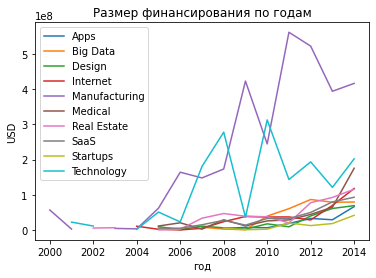

In [120]:
# Строим график
pivot_filt4.plot(
    kind='line',
    title='Размер финансирования по годам', 
    legend=True, 
    xlabel='год', 
    ylabel='USD'
    )
plt.show()

Наиболее быстрый рост показывают сегменты Startups,Apps,Internet,Real Estate, Medical.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель — для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [121]:
#Определим список полей
fin_list2=['venture','equity_crowdfunding','undisclosed','convertible_note','debt_financing','angel','grant',
          'private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']

In [122]:
#Построим первую часть таблицы
grouped12=df_filt.groupby('fin_year')['seed'].sum()

In [123]:
#Сбросим индекс
grouped12=grouped12.reset_index()

In [124]:
#Группируем столбцы с типом финансирования по году
for cat in fin_list2:
    grouped13=df_filt.groupby('fin_year')[cat].sum()
    grouped13=grouped13.reset_index()
    grouped12=grouped12.merge(grouped13,on='fin_year',how='outer')
    
#Проверим,что получилось
print(grouped12)

    fin_year          seed       venture  equity_crowdfunding  undisclosed  \
0       2000  1.675914e+07  3.753622e+08                  0.0  215502640.0   
1       2001  2.639896e+07  2.852207e+08                  0.0   46524067.0   
2       2002  1.046519e+07  3.423629e+08                  0.0   42323731.0   
3       2003  1.531836e+07  4.002344e+08                  0.0   10280000.0   
4       2004  1.810473e+07  7.230162e+08                  0.0   98758160.0   
5       2005  3.942520e+07  4.902948e+09                  0.0    8871332.0   
6       2006  6.679477e+07  9.200694e+09             933057.0   71842903.0   
7       2007  1.922965e+08  1.215159e+10                  0.0  109649902.0   
8       2008  3.020030e+08  1.448512e+10                  0.0  143785523.0   
9       2009  2.843514e+08  1.522608e+10            2049671.0   99687229.0   
10      2010  5.048089e+08  1.787687e+10            7400000.0  218862215.0   
11      2011  1.166553e+09  1.560779e+10            3091684.0  2

In [125]:
#Сбросим индекс
df_r=df_r.reset_index()

In [126]:
#Проверим, какие годы есть в таблице возвратов
print(df_r['year'].unique)

<bound method Series.unique of 0     2000
1     2001
2     2002
3     2003
4     2004
5     2005
6     2006
7     2007
8     2008
9     2009
10    2010
11    2011
12    2012
13    2013
14    2014
Name: year, dtype: int64>


In [127]:
#Создадим датафрейм для заполнения долями возвратов и заполним первый столбец
fundinf_r = pd.DataFrame()
fundinf_r['year']=grouped12['fin_year']

In [128]:
#Рассчитаем по годам долю возвратов для каждого типа финансирования
for cat in fin_list:
    fundinf_r[cat]=1000000*df_r[cat]/(grouped12[cat]+1e-60)

In [129]:
def delete_outlier(x):
    """ 
    Замена выброса на NaN
    """
    if x>10000:
        return np.nan
    else:
        return x

In [130]:
#Заменим выбросы
for cat in fin_list:
    fundinf_r[cat]=fundinf_r[cat].apply(delete_outlier)

In [131]:
#Проверим результат
print(fundinf_r)

    year      seed   venture  equity_crowdfunding  undisclosed  \
0   2000  0.996471  0.147591             0.000000     0.362919   
1   2001  0.109095  0.082357             0.000000     0.462126   
2   2002  0.629707  0.611690             0.000000     0.608878   
3   2003  0.505276  0.584308             0.000000     0.914397   
4   2004  0.548476  0.768862             0.000000     0.336073   
5   2005  0.674695  0.536192             0.000000     1.071992   
6   2006  0.925372  0.336951             0.203632     0.650586   
7   2007  0.366153  0.295054                  NaN     0.504971   
8   2008  0.297083  0.187573                  NaN     0.285286   
9   2009  0.563423  0.164277             0.087819     0.376177   
10  2010  0.525605  0.184560             0.052703     0.238278   
11  2011  0.271989  0.251117             0.097034     0.223676   
12  2012  0.193416  0.310043             0.029199     0.123354   
13  2013  0.147350  0.345142             0.024578     0.243841   
14  2014  

In [132]:
fundinf_r=fundinf_r.set_index('year')

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

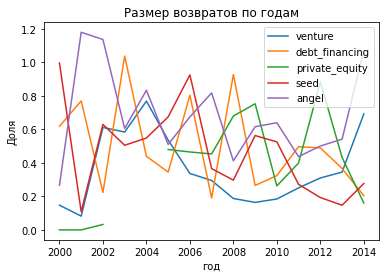

In [133]:
# Строим график
fundinf_r[['venture','debt_financing','private_equity','seed','angel']].plot(
    kind='line',
    title='Размер возвратов по годам', 
    legend=True, 
    xlabel='год', 
    ylabel='Доля'
    )
plt.show()

Выбранные типы финансирования не демонстрируют какой-то положительной динамики возвратов, возвраты колеблются вокруг средней. С 2008 по 2014 наблюдается рост возвратов venture, до этого показатель по этому типу финансирования падал.

По типу venture график напоминает параболу, то есть однозначно нельзя сказать, что этот метод становится все более эффективным за весь период, эффективность типа seed несмотря на периодические скачки вверх демонстрирует тенденцию к снижению эффективности, схожая ситуация наблюдается по debt_fianancing - тренд на снижение несмотря на отскоки вверх. По остальным типам финансирования каких-либо четких закономерностей не выявлено.


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



Необходимо инвестировать в массовые сегменты (наиболее быстрый рост финансирования демонстрируют сегменты Startups,Apps,Internet,Real Estate, Medical), тип финансирования выбрать venture - это самый распространенный тип финансирования по объму и количеству компаний, который демонстрирует рост возвратов после кризиса 2008

Был проведен анализ датасетов cb_investments и cb_returns, удалены дубликаты и не содержащие информацию о финансировании данные (24.7% данных). Была проведена категоризация данных - наибольшая по количеству сегментов категория - нишевая, наибольшая по количеству компаний - массовый сегмент [2](#link2), 59% компаний получают единичное финансирование, по объему лидирует срок финансирования до года - 62% [3](#link3). Были проанализированы и отброшены выбросы по методу IQR, сегмент рынка с наибольшей долей выбросов - недвижимость (17.2%).[4](#link4) Самый распространенный по количеству компаний (19060) и по объему финансирования (133 987 229)- венчур [5](#link5), венчур демонстрирует рост доли возвратов после падения в кризис 2008 года. Типичный размер раунда финансирования снижается, а количество раундов возрастает (тенция нарушилась в 2012 году)[6](#link6). Наиболее быстрый рост финансирования показывают сегменты Startups,Apps,Internet,Real Estate, Medical [7](#link7). Стоит отметить, что на выводы могут существенно повлиять выбросы, вопрос, насколько было правомерным отбрасывать данные.